In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import RobustScaler, LabelEncoder

## 1. Definición del Problema
Este proyecto propone construir un modelo de clasificación supervisada que, a partir de datos demográficos y socioeconómicos de una persona adulta (edad, nivel educativo, ocupación, estado civil, país de origen, etc.), prediga si dicha persona ganará más o menos de 50,000 USD al año.

En base a los resultados del modelo, los estudiantes deberán desarrollar un sistema de recomendación interpretativo, capaz de sugerir posibles estrategias o cambios para aumentar la probabilidad de superar ese umbral de ingresos.
Objetivos

    Explorar los datos del censo.
    Construir perfiles socioeconómicos.
    Explorar la importancia y peso de variables sociales (educación, género, raza, etc.) en predicciones económicas.
    Aplicar técnicas de sistemas de recomendación.
    Visualizar y comunicar hallazgos de forma profesional.


## 2. Recopilación de Datos

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/4GeeksAcademy/predicting-your-future-with-data/main/adult-census-income.csv')


df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


# 3. Análisis Descriptivo

In [3]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


En principio no hay valores nulos, pero si nos fijamos este csv trata los valores nulos como '?' en columnas categoricas asi que tendremos que imputarlos mas adelante.


### Entre las variables numericas tenemos 

-age, con un rango amplio y una mediana de 37 años, 

-'education.num' va de 1 al 16 y con una media de 10 podemos decir que la mayoria tiene educacion secundaria,

-'capital.gain' y 'capital.loss' son similares, solo una minoria tiene perdidas significativas o tiene ganancias altas.

-Luego tenemos 'hours.per.week' siendo la media 40 y teniendo valores de hasta 99 podemos decir que hay outliers que se tienen que tratar 

-Por ultimo fnlwgt que es el peso que tiene la persona en relacion a las demas, es decir cuanta gente esta en el mismo grupo

### Entre las variables categoricas

-Hay 9 variables categoricas workclass, education, marital.status, occupation, relationship, race, sex, native.country, e income (la variable objetivo)

-education por ejemplo la podriamos quitar porque ya tenemos education.num que esta factorizada y nos sirve mas, luego occupation y marital.status tambien pueden tener correlacion con el ingreso

## 4. Limpieza de datos

    Eliminar Duplicados
    Eliminar información irrelevante




In [5]:

df.duplicated().sum()

np.int64(24)

Elimino la columna fnlwgt porque me falta la información necesaria para saber que representa, y luego education porque ya tengo la columna education.num en numérica que representa lo mismo de manera mas útil

# Análisis de Variables

#### Análisis de Variables Univariante

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'fnlwgt'}>],
       [<Axes: title={'center': 'education.num'}>,
        <Axes: title={'center': 'capital.gain'}>],
       [<Axes: title={'center': 'capital.loss'}>,
        <Axes: title={'center': 'hours.per.week'}>]], dtype=object)

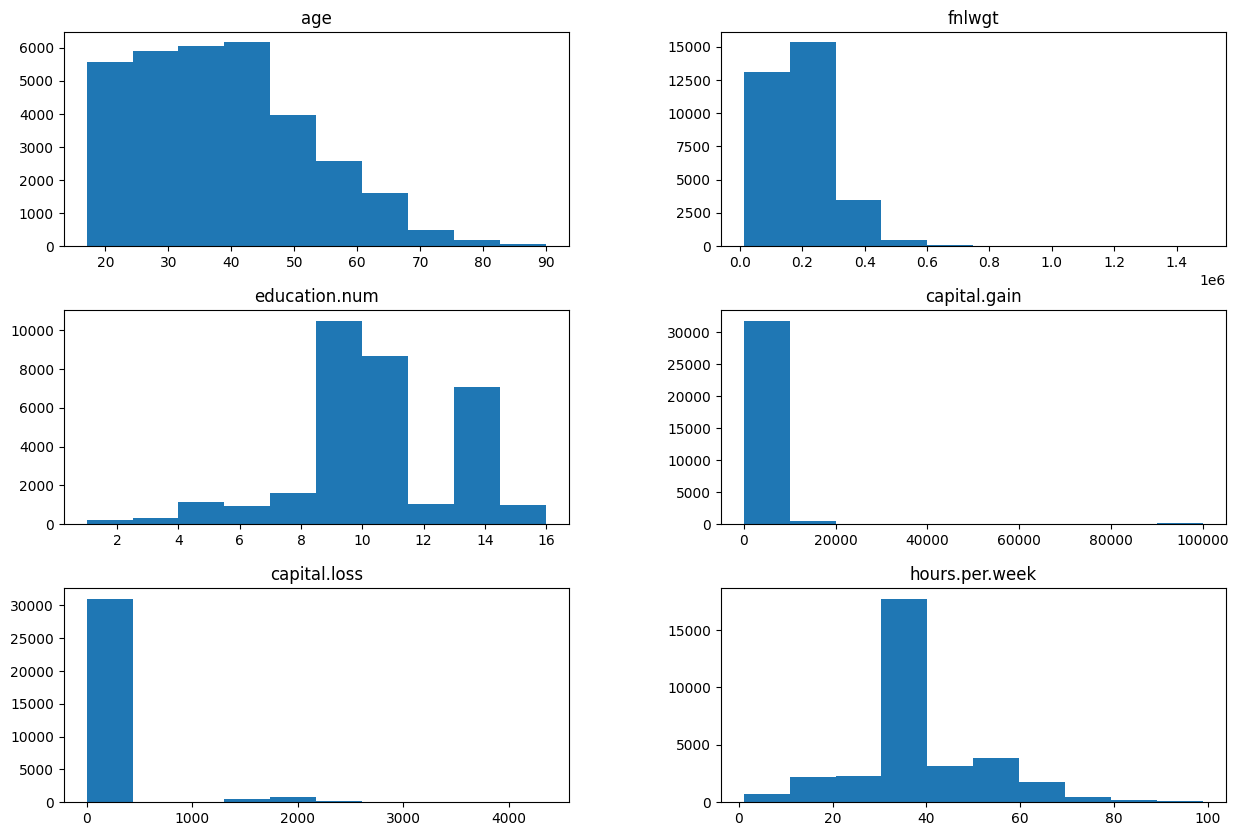

In [6]:
df.hist(figsize=(15, 10), grid=False)

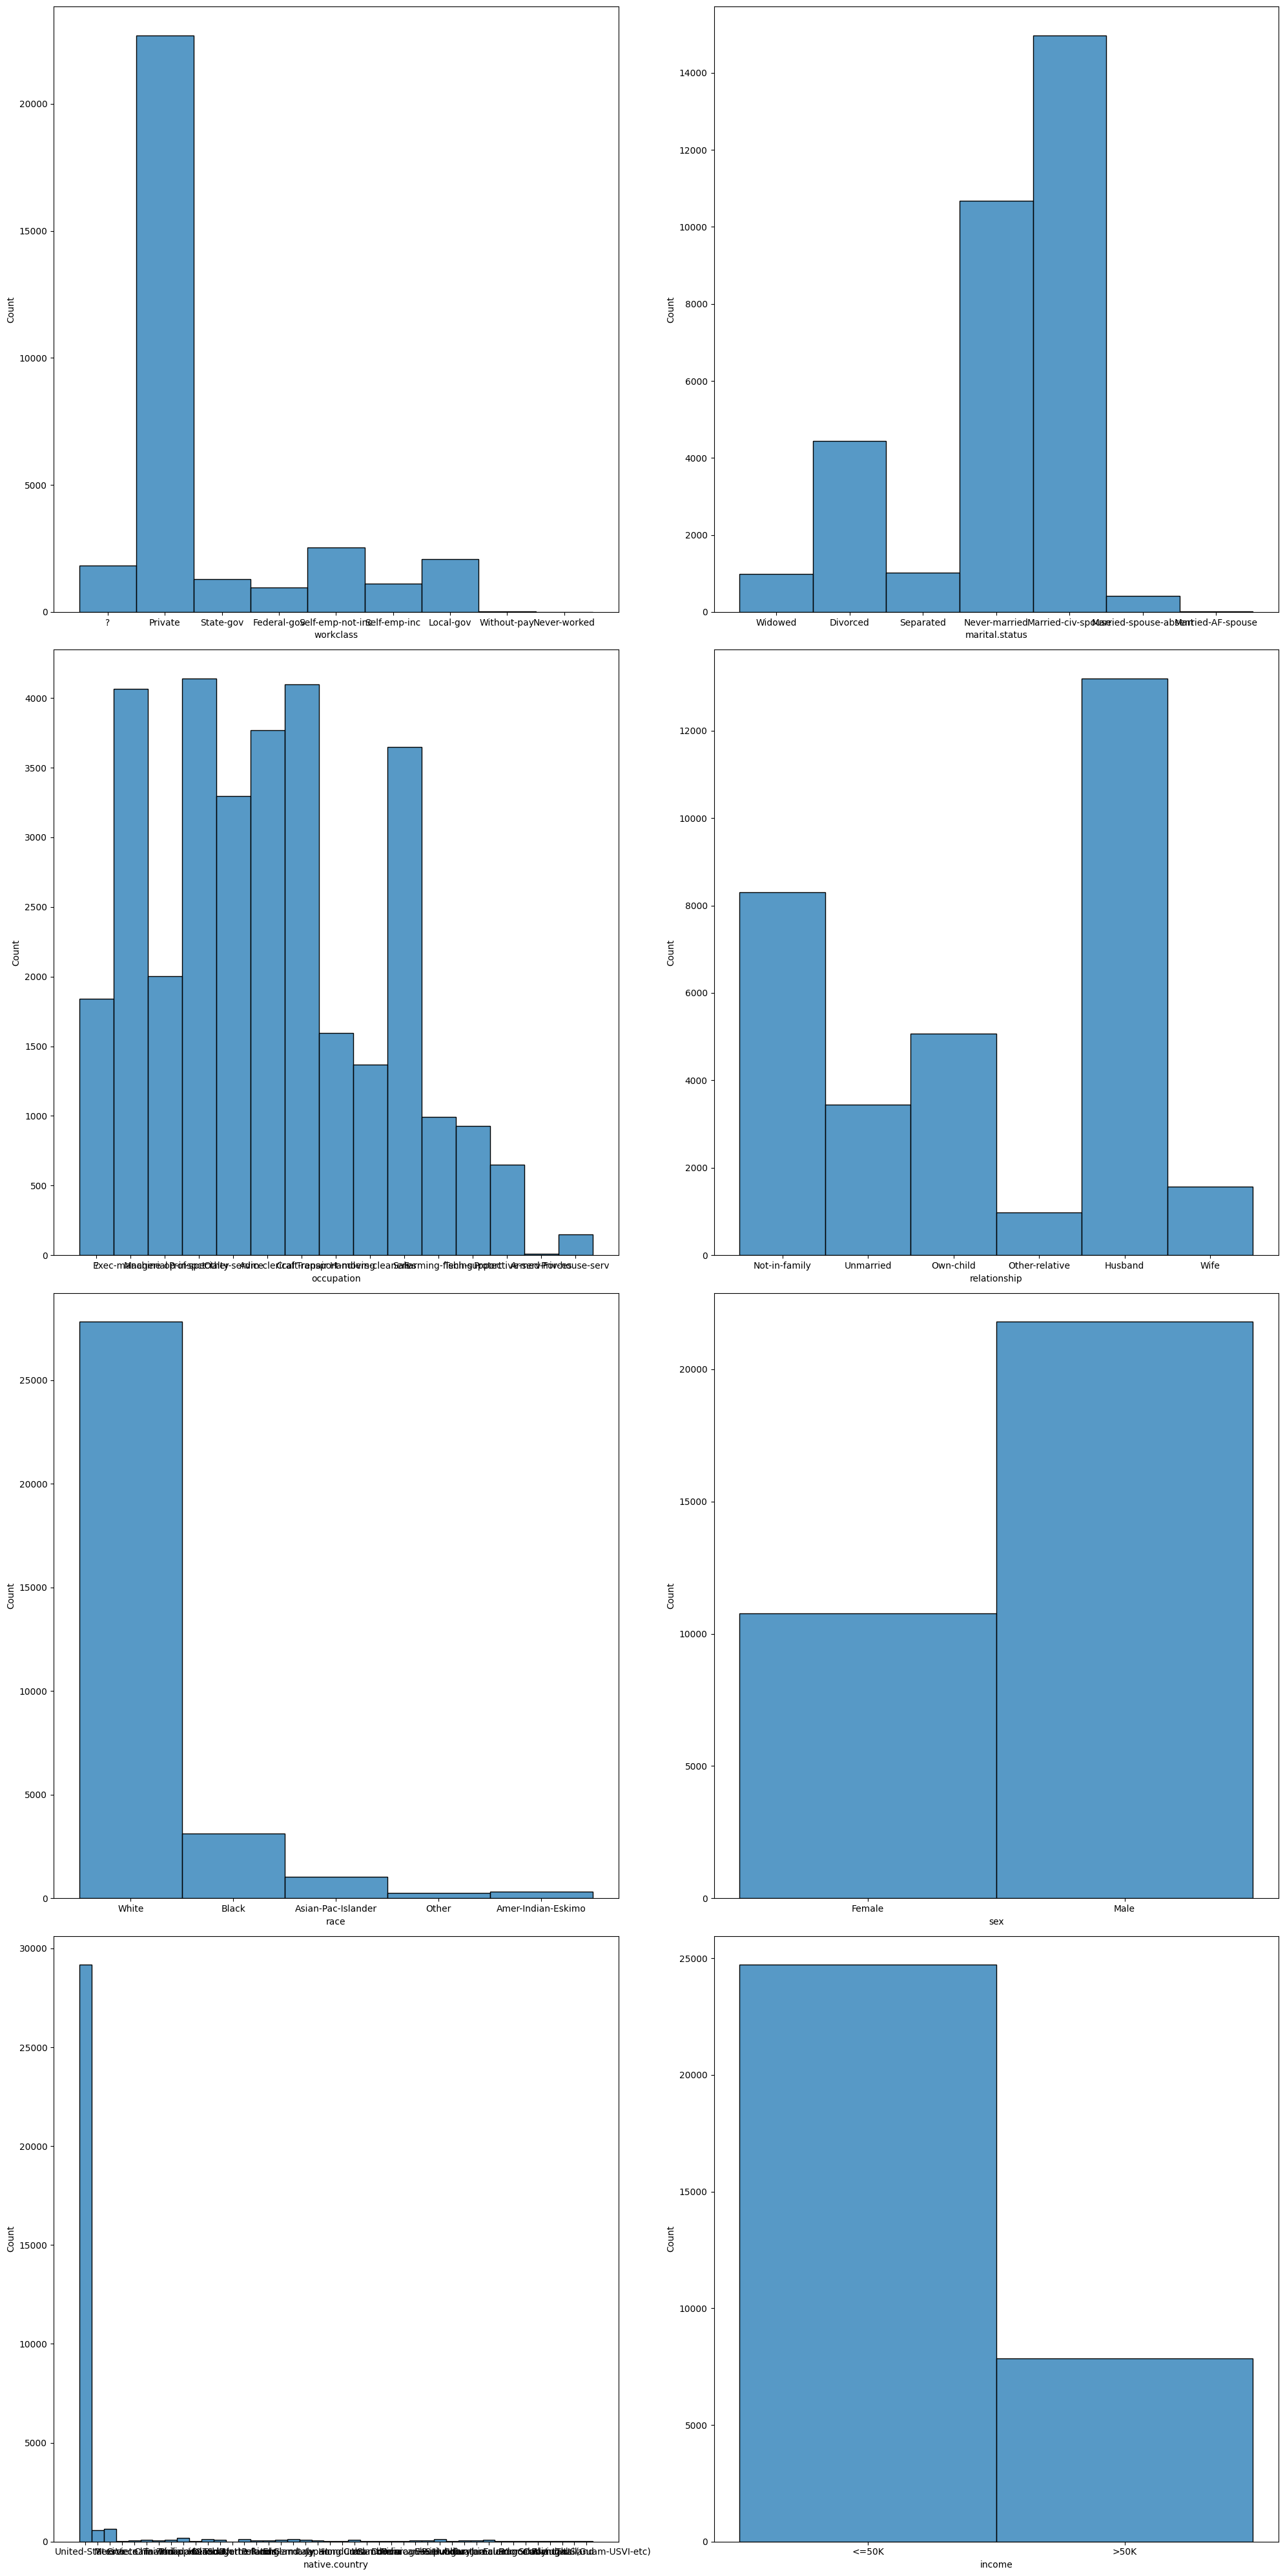

In [7]:
fig, axs = plt.subplots(4, 2, figsize=(20,40))

sns.histplot(ax=axs[0, 0], data=df, x="workclass")
sns.histplot(ax=axs[0, 1], data=df, x="marital.status")
sns.histplot(ax=axs[1, 0], data=df, x="occupation")
sns.histplot(ax=axs[1, 1], data=df, x="relationship")
sns.histplot(ax=axs[2, 0], data=df, x="race")
sns.histplot(ax=axs[2, 1], data=df, x="sex")
sns.histplot(ax=axs[3, 0], data=df, x="native.country")
sns.histplot(ax=axs[3, 1], data=df, x="income")

plt.tight_layout()
plt.show()

#### Análisis de Variables Multivariante

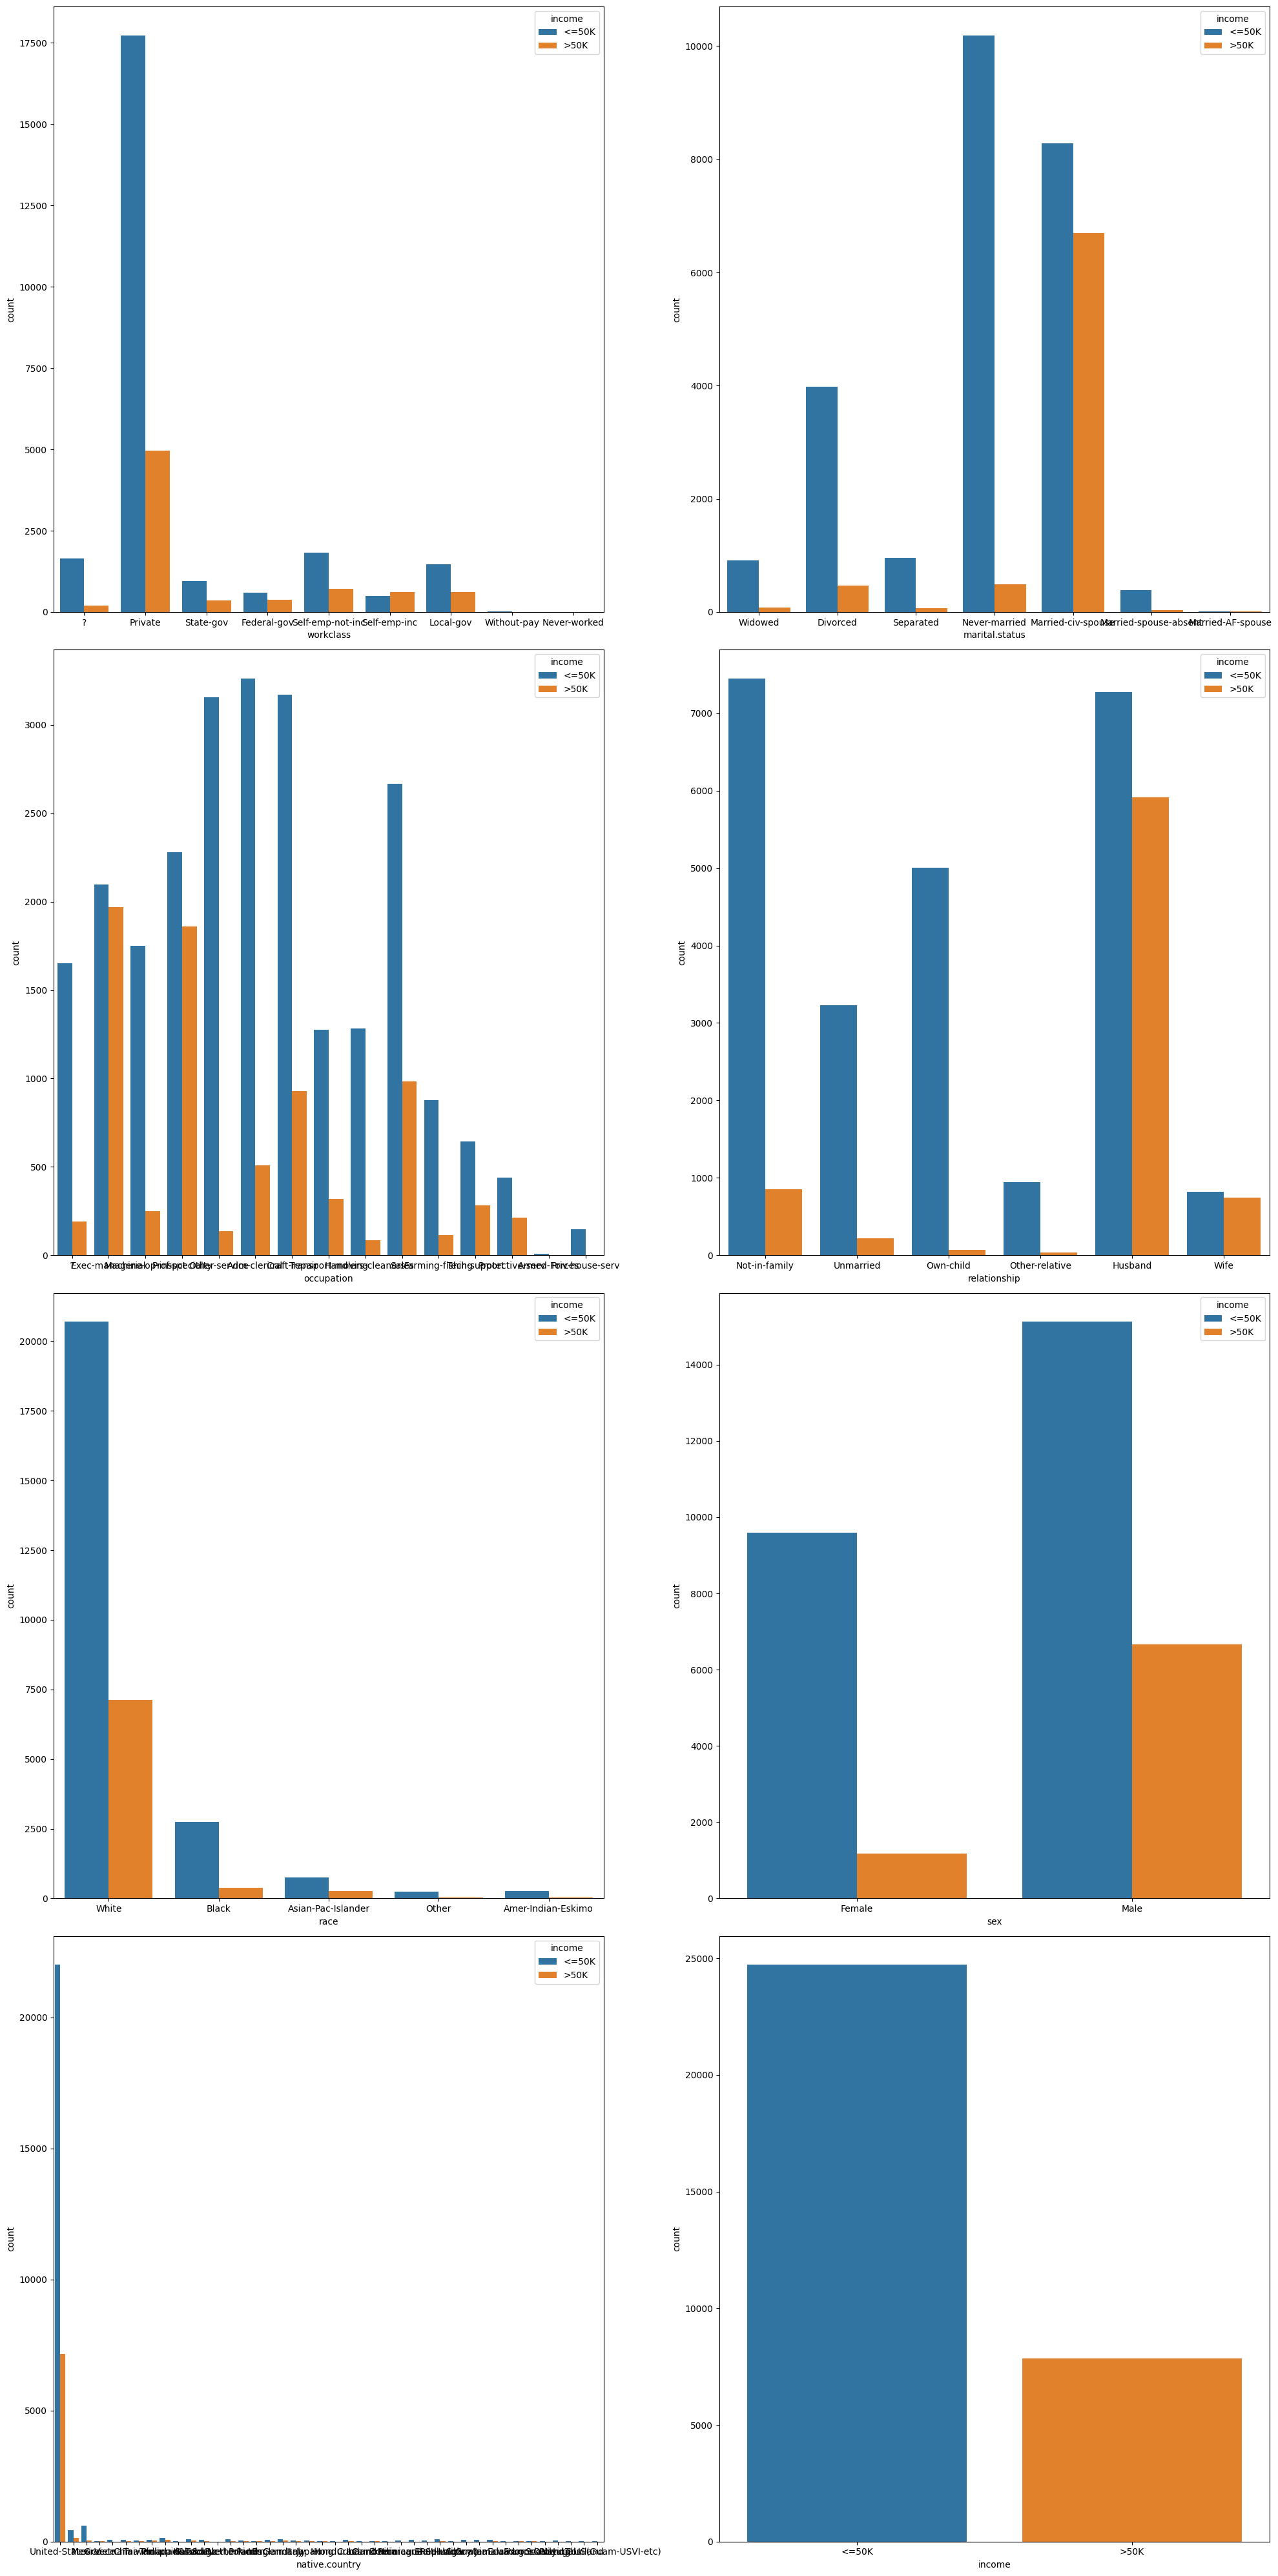

In [8]:
fig, axs = plt.subplots(4, 2, figsize=(20,40))

sns.countplot(ax=axs[0, 0], data=df, x="workclass", hue='income')
sns.countplot(ax=axs[0, 1], data=df, x="marital.status", hue='income')
sns.countplot(ax=axs[1, 0], data=df, x="occupation", hue='income')
sns.countplot(ax=axs[1, 1], data=df, x="relationship", hue='income')
sns.countplot(ax=axs[2, 0], data=df, x="race", hue='income')
sns.countplot(ax=axs[2, 1], data=df, x="sex", hue='income')
sns.countplot(ax=axs[3, 0], data=df, x="native.country", hue='income')
sns.countplot(ax=axs[3, 1], data=df, x="income", hue='income')

plt.tight_layout()
plt.show()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [10]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


Se pueden observar una gran cantidad de outliers en todas las variables numéricas

Tambien tenemos datos faltantes en algunas de las columnas, las cuales estan representados en este dataframe por el símbolo '?', lo que haremos será cambiar ese símbolo por un nulo para después eliminarlos

In [11]:
df.replace('?', np.nan, inplace=True)
df.isna()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
32557,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
32558,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
32559,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [12]:
df.isnull().sum().sort_values(ascending=False)

occupation        1843
workclass         1836
native.country     583
fnlwgt               0
education            0
education.num        0
age                  0
marital.status       0
relationship         0
sex                  0
race                 0
capital.gain         0
capital.loss         0
hours.per.week       0
income               0
dtype: int64

In [13]:
df.dropna(axis=0, inplace=True)
df.shape

(30162, 15)

# Split

Nuestra variable objetivo en este caso es el [Income], para ello la deberemos cambiar primero su formato antes de hacer el split, haremos que 1 sea la gente que cobra mas de 50k y 0 la que menos

In [14]:
df.loc[df['income']==1]

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income


Encoding y Scaler

In [15]:
df['income'] = df['income'].str.strip()
df['high_income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

In [16]:
features = ['age','education', 'marital.status', 'occupation', 'hours.per.week', 'sex', 'native.country']
X = df[features]
y = df['high_income']

numeric_features = ['age', 'hours.per.week']
categorical_features = ['education', 'marital.status', 'occupation', 'sex', 'native.country']

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [17]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [18]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(6033,))

In [20]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8209845847836897

In [21]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.86      0.91      0.88      4533
           1       0.67      0.54      0.60      1500

    accuracy                           0.82      6033
   macro avg       0.77      0.73      0.74      6033
weighted avg       0.81      0.82      0.81      6033



In [29]:
def recommend_trajectory(user_profile):
    """
    user_profile debe ser un diccionario con keys:
    - age, education, marital.status, occupation, hours.per.week, sex, native.country
    """
    user_df = pd.DataFrame([user_profile])
    prediction = model.predict(user_df)[0]
    prob = model.predict_proba(user_df)[0][1]
    if prediction == 1:
        return f"✅ Con este perfil, tu probabilidad de ganar más de 50K es del {prob*100:.1f}%."
    else:
        return f"⚠️ Con este perfil, tu probabilidad de superar los 50K es solo del {prob*100:.1f}%. Considera mejorar tu educación o cambiar de ocupación."



In [30]:
# Simulación de usuario
simulated_user = {
    "age": 46,
    "education": "HS-grad",
    "marital.status": "Married",
    "occupation": "Sales",
    "hours.per.week": 40,
    "sex": "Female",
    "native.country": "United-States"
}
recommend_trajectory(simulated_user)

'⚠️ Con este perfil, tu probabilidad de superar los 50K es solo del 12.1%. Considera mejorar tu educación o cambiar de ocupación.'